<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

### Load the data


In [5]:
conn = sqlite3.connect('survey-data.sqlite')
QUERY = """SELECT *
FROM main;
"""
df = pd.read_sql_query(QUERY, conn)

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [7]:
QUERY = """SELECT Age, JobSatPoints_6, JobSatPoints_7
FROM main
WHERE Age IS NOT NULL
AND Age != 'Prefer not to say'
AND JobSatPoints_6 IS NOT NULL
AND JobSatPoints_7 IS NOT NULL
"""
stacked_jobsat = pd.read_sql_query(QUERY, conn)
stacked_jobsat.head()

,Age,JobSatPoints_6,JobSatPoints_7
0,35-44 years old,0.0,0.0
1,35-44 years old,25.0,10.0
2,35-44 years old,30.0,0.0
3,45-54 years old,0.0,0.0
4,25-34 years old,60.0,10.0


In [8]:
stacked_jobsat = stacked_jobsat.replace('Under 18 years old', '13-17 years old') # puts groups in more readable order on plot
stacked_jobsat

,Age,JobSatPoints_6,JobSatPoints_7
0,35-44 years old,0.0,0.0
1,35-44 years old,25.0,10.0
2,35-44 years old,30.0,0.0
3,45-54 years old,0.0,0.0
4,25-34 years old,60.0,10.0
...,...,...,...
29368,45-54 years old,0.0,0.0
29369,25-34 years old,0.0,0.0
29370,18-24 years old,60.0,70.0
29371,25-34 years old,0.0,0.0


In [9]:
JobSat_6 = stacked_jobsat.groupby('Age')['JobSatPoints_6'].median()
JobSat_7 = stacked_jobsat.groupby('Age')['JobSatPoints_7'].median()

In [10]:
JobSat_6

Age
13-17 years old       1.5
18-24 years old      15.0
25-34 years old      20.0
35-44 years old      20.0
45-54 years old      20.0
55-64 years old      20.0
65 years or older    20.0
Name: JobSatPoints_6, dtype: float64

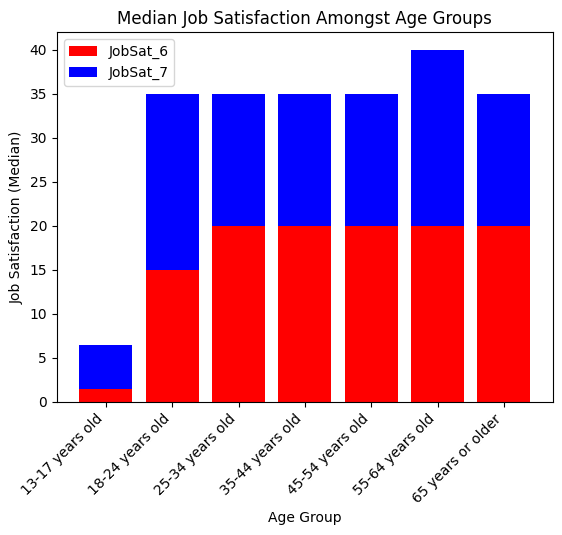

In [11]:
plt.bar(JobSat_6.index,
        JobSat_6,
        color = 'r')
plt.bar(JobSat_7.index,
        JobSat_7,
        bottom = JobSat_6,
        color= 'b')
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction (Median)')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Median Job Satisfaction Amongst Age Groups')
plt.legend(['JobSat_6', 'JobSat_7'])
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [12]:
QUERY = """SELECT Employment, JobSatPoints_6, JobSatPoints_7
FROM main
WHERE Employment IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
AND JobSatPoints_7 IS NOT NULL
"""
df_emp_sat = pd.read_sql_query(QUERY, conn)
df_emp_sat.head(10)

,Employment,JobSatPoints_6,JobSatPoints_7
0,"Employed, full-time",0.0,0.0
1,"Employed, full-time",25.0,10.0
2,"Employed, full-time",30.0,0.0
3,"Employed, full-time",0.0,0.0
4,"Employed, full-time",60.0,10.0
5,"Employed, full-time",100.0,90.0
6,"Employed, full-time",20.0,20.0
7,"Employed, full-time;Student, part-time",0.0,0.0
8,"Employed, full-time",25.0,20.0
9,"Employed, full-time;Independent contractor, fr...",50.0,20.0


In [13]:
df_emp_sat['EmpSplit'] = df_emp_sat['Employment'].str.split(';')
df_emp_sat = df_emp_sat.drop('Employment', axis = 1)
df_emp_sat = df_emp_sat.explode('EmpSplit').reset_index(drop = True)
df_emp_sat.head(10)

,JobSatPoints_6,JobSatPoints_7,EmpSplit
0,0.0,0.0,"Employed, full-time"
1,25.0,10.0,"Employed, full-time"
2,30.0,0.0,"Employed, full-time"
3,0.0,0.0,"Employed, full-time"
4,60.0,10.0,"Employed, full-time"
5,100.0,90.0,"Employed, full-time"
6,20.0,20.0,"Employed, full-time"
7,0.0,0.0,"Employed, full-time"
8,0.0,0.0,"Student, part-time"
9,25.0,20.0,"Employed, full-time"


In [14]:
stacked_emp_sat = df_emp_sat.groupby('EmpSplit')['JobSatPoints_6'].mean().reset_index()

In [15]:
stacked_emp_sat

,EmpSplit,JobSatPoints_6
0,"Employed, full-time",24.407637
1,"Employed, part-time",23.867863
2,"Independent contractor, freelancer, or self-em...",24.636829
3,"Not employed, and not looking for work",19.640000
4,"Not employed, but looking for work",25.202703
5,Retired,24.080000
6,"Student, full-time",22.174858
7,"Student, part-time",24.080797


In [16]:
stacked_emp_sat = stacked_emp_sat.join(df_emp_sat.groupby('EmpSplit')['JobSatPoints_7'].mean().reset_index()['JobSatPoints_7'])
stacked_emp_sat

,EmpSplit,JobSatPoints_6,JobSatPoints_7
0,"Employed, full-time",24.407637,22.943472
1,"Employed, part-time",23.867863,24.811854
2,"Independent contractor, freelancer, or self-em...",24.636829,23.861423
3,"Not employed, and not looking for work",19.640000,14.640000
4,"Not employed, but looking for work",25.202703,22.959459
5,Retired,24.080000,26.040000
6,"Student, full-time",22.174858,26.014178
7,"Student, part-time",24.080797,25.578174


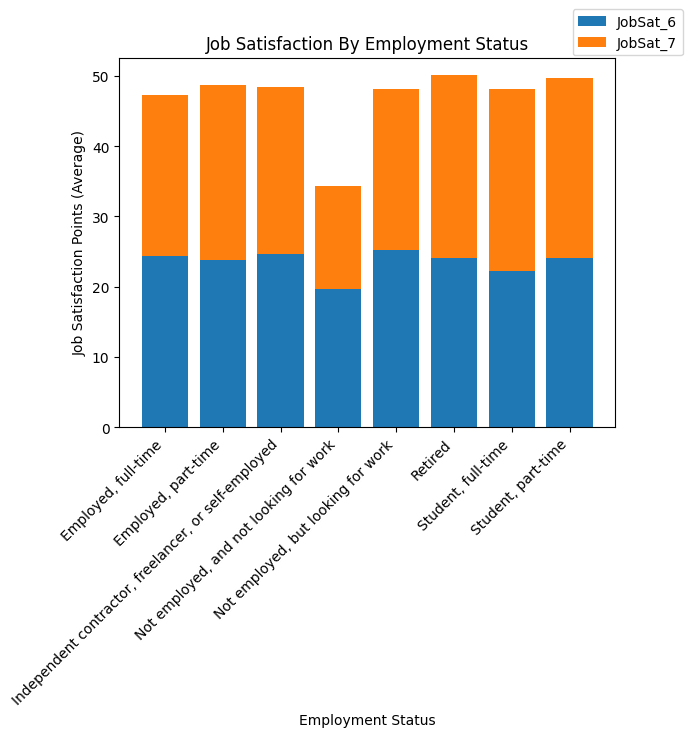

In [17]:
plt.bar(stacked_emp_sat['EmpSplit'],
        stacked_emp_sat['JobSatPoints_6'])
plt.bar(stacked_emp_sat['EmpSplit'],
        stacked_emp_sat['JobSatPoints_7'],
        bottom = stacked_emp_sat['JobSatPoints_6'])
plt.xlabel('Employment Status')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Job Satisfaction Points (Average)')
plt.title('Job Satisfaction By Employment Status')
plt.legend(['JobSat_6', 'JobSat_7'],
           bbox_to_anchor = (1.15,1.15))
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [18]:
QUERY = """SELECT Age, ConvertedCompYearly, JobSatPoints_6
FROM main
WHERE Age == '25-34 years old'
AND ConvertedCompYearly IS NOT NULL
AND JobSatPoints_6 IS NOT NULL
"""
df_comp_sat = pd.read_sql_query(QUERY, conn)
df_comp_sat.head(), df_comp_sat.shape # learning shape to note for removing half of dataset

(               Age  ConvertedCompYearly  JobSatPoints_6
 0  25-34 years old             110000.0            20.0
 1  25-34 years old              29000.0             0.0
 2  25-34 years old              66592.0            30.0
 3  25-34 years old             230000.0             0.0
 4  25-34 years old             146496.0            30.0,
 (7431, 3))

In [19]:
df_comp_sat = df_comp_sat.sample(n = round(len(df_comp_sat)/2)) # removing half of the dataset to approx half the age group
df_comp_sat.shape

(3716, 3)

In [20]:
stacked_med_comp = df_comp_sat.groupby('Age')['ConvertedCompYearly'].median()
stacked_med_sat = df_comp_sat.groupby('Age')['JobSatPoints_6'].median()

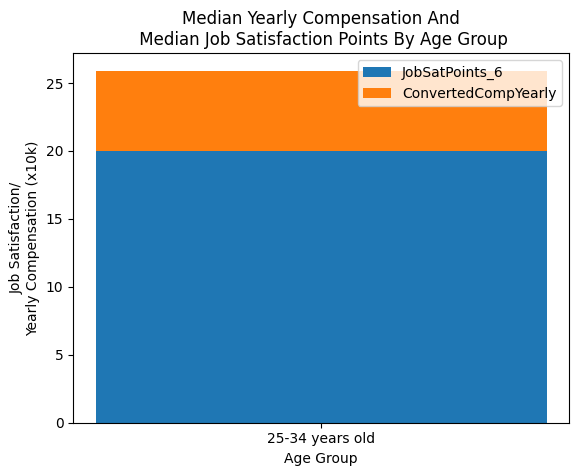

In [21]:
plt.bar(stacked_med_sat.index,
        stacked_med_sat)
plt.bar(stacked_med_comp.index,
        stacked_med_comp/10000,
        bottom = stacked_med_sat)
plt.xlabel('Age Group')
plt.ylabel('Job Satisfaction/\nYearly Compensation (x10k)')
plt.title('Median Yearly Compensation And\n Median Job Satisfaction Points By Age Group')
plt.legend(['JobSatPoints_6', 'ConvertedCompYearly'],
           loc = 'upper right')
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [22]:
QUERY = """SELECT Age, ConvertedCompYearly, JobSat
FROM main
WHERE Age IS NOT NULL
AND Age != 'Prefer not to say'
AND JobSat IS NOT NULL
AND ConvertedCompYearly IS NOT NULL
"""
df_sat_comp = pd.read_sql_query(QUERY, conn)
df_sat_comp.head()

,Age,ConvertedCompYearly,JobSat
0,18-24 years old,7322.0,10.0
1,35-44 years old,91295.0,10.0
2,25-34 years old,110000.0,10.0
3,35-44 years old,161044.0,7.0
4,45-54 years old,195000.0,5.0


In [23]:
df_sat_comp = df_sat_comp.replace('Under 18 years old', '13-17 years old') # puts the groups in order for readability

q1 = df_sat_comp['ConvertedCompYearly'].quantile(.25) # removing outliers for visual clarity
q3 = df_sat_comp['ConvertedCompYearly'].quantile(.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
df_sat_comp = df_sat_comp[df_sat_comp['ConvertedCompYearly'] <= upper_bounds].reset_index(drop = True)
df_sat_comp.head()

,Age,ConvertedCompYearly,JobSat
0,18-24 years old,7322.0,10.0
1,35-44 years old,91295.0,10.0
2,25-34 years old,110000.0,10.0
3,35-44 years old,161044.0,7.0
4,45-54 years old,195000.0,5.0


In [24]:
df_sat_comp['JobSat'].value_counts(), df_sat_comp['ConvertedCompYearly'].describe() # looking how to scale down comp for vis

(JobSat
 8.0     3970
 7.0     3390
 6.0     1989
 9.0     1913
 10.0    1108
 5.0      978
 4.0      653
 3.0      633
 2.0      442
 0.0      166
 1.0      149
 Name: count, dtype: int64,
 count     15391.000000
 mean      71633.874212
 std       50710.108290
 min           1.000000
 25%       32222.000000
 50%       64444.000000
 75%      101770.000000
 max      218079.000000
 Name: ConvertedCompYearly, dtype: float64)

In [25]:
stacked_sat_comp = df_sat_comp
stacked_sat_comp['ConvertedCompYearly'] = df_sat_comp['ConvertedCompYearly'] / 10000 # scaling to 10s like 'sat'
stacked_sat_comp

,Age,ConvertedCompYearly,JobSat
0,18-24 years old,0.7322,10.0
1,35-44 years old,9.1295,10.0
2,25-34 years old,11.0000,10.0
3,35-44 years old,16.1044,7.0
4,45-54 years old,19.5000,5.0
...,...,...,...
15386,18-24 years old,0.9571,6.0
15387,18-24 years old,1.5637,6.0
15388,18-24 years old,0.9711,0.0
15389,45-54 years old,17.0000,9.0


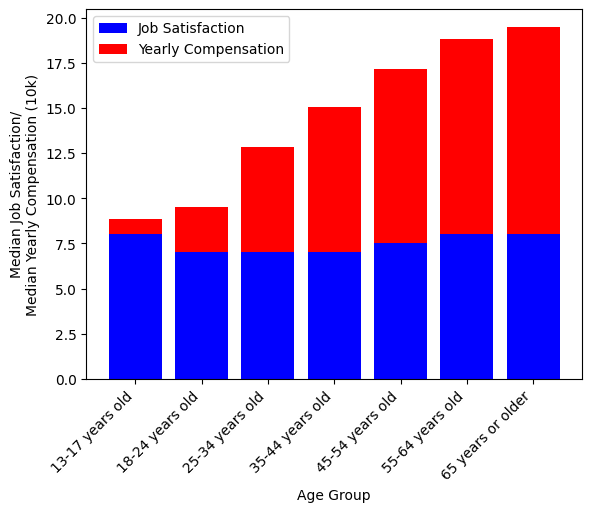

In [26]:
stacked_comp = stacked_sat_comp.groupby('Age')['ConvertedCompYearly'].median()
stacked_sat = stacked_sat_comp.groupby('Age')['JobSat'].median()

plt.bar(stacked_sat.index,
        stacked_sat,
        color = 'b')
plt.bar(stacked_comp.index,
        stacked_comp,
        color = 'r',
        bottom = stacked_sat)
plt.xlabel('Age Group')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Median Job Satisfaction/\nMedian Yearly Compensation (10k)')
plt.legend(['Job Satisfaction', 'Yearly Compensation'])
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [27]:
QUERY = """SELECT Age, DatabaseWantToWorkWith
FROM main
WHERE Age IS NOT NULL
AND DatabaseWantToWorkWith IS NOT NULL
AND Age != 'Prefer not to say'
"""

df_age_lang = pd.read_sql_query(QUERY, conn)
df_age_lang.head()

,Age,DatabaseWantToWorkWith
0,35-44 years old,PostgreSQL
1,45-54 years old,Firebase Realtime Database
2,18-24 years old,MongoDB;MySQL;PostgreSQL
3,18-24 years old,PostgreSQL;SQLite
4,Under 18 years old,Cloud Firestore


In [28]:
df_age_lang = df_age_lang.replace('Under 18 years old', '13-17 years old') # puts columns in numerical order after groupby
df_age_lang['Database'] = df_age_lang['DatabaseWantToWorkWith'].str.split(';') # split list into new column
df_age_lang = df_age_lang.explode('Database') # explode list
df_age_lang = df_age_lang.drop('DatabaseWantToWorkWith', axis = 1) # drop original column
df_age_lang = df_age_lang.reset_index(drop = True) # reset due to duplicate indices
df_age_lang

,Age,Database
0,35-44 years old,PostgreSQL
1,45-54 years old,Firebase Realtime Database
2,18-24 years old,MongoDB
3,18-24 years old,MySQL
4,18-24 years old,PostgreSQL
...,...,...
127079,18-24 years old,PostgreSQL
127080,18-24 years old,SQLite
127081,18-24 years old,MongoDB
127082,18-24 years old,MySQL


In [29]:
top5 = list(df_age_lang.value_counts(subset = 'Database').head().index) # attaining top 5
rows = df_age_lang.loc[df_age_lang['Database'].isin(top5) == False] # list of rows to drop that do not contain top 5
df_age_lang = df_age_lang.drop(rows.index) # dropping indices of rows to drop
df_age_lang.head()

,Age,Database
0,35-44 years old,PostgreSQL
2,18-24 years old,MongoDB
3,18-24 years old,MySQL
4,18-24 years old,PostgreSQL
5,18-24 years old,PostgreSQL


In [30]:
stacked_age_lang = df_age_lang.groupby('Age')['Database'].value_counts().reset_index()
stacked_age_lang

,Age,Database,count
0,13-17 years old,SQLite,508
1,13-17 years old,PostgreSQL,506
2,13-17 years old,MySQL,411
3,13-17 years old,MongoDB,374
4,13-17 years old,Redis,209
5,18-24 years old,PostgreSQL,5113
6,18-24 years old,MySQL,3077
7,18-24 years old,SQLite,3052
8,18-24 years old,MongoDB,3027
9,18-24 years old,Redis,2235


In [31]:
stacked_age_lang = stacked_age_lang.pivot(index = 'Age',
                                          columns = 'Database',
                                          values = 'count')
stacked_age_lang

Database,MongoDB,MySQL,PostgreSQL,Redis,SQLite
Age,,,,,
13-17 years old,374,411,506,209,508
18-24 years old,3027,3077,5113,2235,3052
25-34 years old,4363,4465,9523,4542,4897
35-44 years old,2140,2536,5769,2779,3060
45-54 years old,773,1125,2201,865,1293
55-64 years old,234,471,724,176,493
65 years or older,45,143,108,20,131


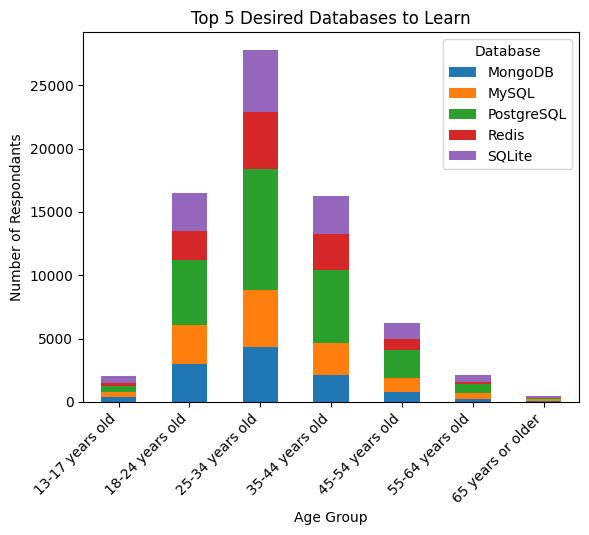

In [32]:
stacked_age_lang.plot(kind = 'bar',
                      stacked = True)
plt.xlabel('Age Group')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Number of Respondants')
plt.title('Top 5 Desired Databases to Learn')
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [33]:
QUERY = """SELECT JobSat, Employment
FROM main
WHERE JobSat IS NOT NULL
AND Employment IS NOT NULL
"""
df_sat_emp = pd.read_sql_query(QUERY, conn)
df_sat_emp.head() 

,JobSat,Employment
0,8.0,"Employed, full-time"
1,8.0,"Employed, full-time"
2,5.0,"Employed, full-time"
3,10.0,"Employed, full-time"
4,6.0,"Employed, full-time"


In [34]:
df_sat_emp['Employment Status'] = df_sat_emp['Employment'].str.split(';')
df_sat_emp = df_sat_emp.explode('Employment Status')
df_sat_emp = df_sat_emp.drop('Employment', axis = 1)
df_sat_emp = df_sat_emp.reset_index(drop = True)
df_sat_emp['Employment Status'].value_counts() # checking if all values are good for visualization

Employment Status
Employed, full-time                                     26231
Independent contractor, freelancer, or self-employed     4275
Employed, part-time                                      1808
Student, full-time                                       1021
Student, part-time                                        943
Not employed, but looking for work                        141
Retired                                                    23
Not employed, and not looking for work                     23
Name: count, dtype: int64

In [35]:
df_sat_emp = df_sat_emp.groupby('JobSat')['Employment Status'].value_counts(normalize = True).reset_index()
df_sat_emp

,JobSat,Employment Status,proportion
0,0.0,"Employed, full-time",0.754011
1,0.0,"Independent contractor, freelancer, or self-em...",0.106952
2,0.0,"Employed, part-time",0.050802
3,0.0,"Student, part-time",0.048128
4,0.0,"Student, full-time",0.018717
...,...,...,...
79,10.0,"Student, full-time",0.027818
80,10.0,"Student, part-time",0.020954
81,10.0,"Not employed, but looking for work",0.004697
82,10.0,Retired,0.002168


In [36]:
df_sat_emp['proportion'] = df_sat_emp['proportion'].mul(100, fill_value = 0) # percentage will be more readable
df_sat_emp

,JobSat,Employment Status,proportion
0,0.0,"Employed, full-time",75.401070
1,0.0,"Independent contractor, freelancer, or self-em...",10.695187
2,0.0,"Employed, part-time",5.080214
3,0.0,"Student, part-time",4.812834
4,0.0,"Student, full-time",1.871658
...,...,...,...
79,10.0,"Student, full-time",2.781792
80,10.0,"Student, part-time",2.095376
81,10.0,"Not employed, but looking for work",0.469653
82,10.0,Retired,0.216763


In [37]:
df_sat_emp = df_sat_emp.pivot(index = 'JobSat',
                              columns = 'Employment Status',
                              values = 'proportion')
df_sat_emp

Employment Status,"Employed, full-time","Employed, part-time","Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time"
JobSat,,,,,,,,
0.0,75.401070,5.080214,10.695187,0.267380,1.604278,0.267380,1.871658,4.812834
1.0,71.893491,8.284024,10.946746,0.591716,1.479290,0.295858,2.958580,3.550296
2.0,74.731183,5.806452,10.967742,NaN,0.967742,NaN,2.795699,4.731183
3.0,75.017947,6.030151,10.337401,NaN,0.933238,0.071788,3.732950,3.876525
4.0,73.538012,6.359649,12.207602,NaN,0.657895,0.146199,3.216374,3.874269
5.0,75.960293,5.783341,11.609840,0.129478,0.863185,0.043159,2.848511,2.762192
6.0,76.558995,5.607896,10.969044,0.067295,0.336474,0.022432,3.342306,3.095559
7.0,77.480865,5.210152,11.454277,0.040285,0.335706,0.013428,3.115348,2.349940
8.0,76.812252,4.946115,12.490074,0.045377,0.136132,0.034033,2.881452,2.654566


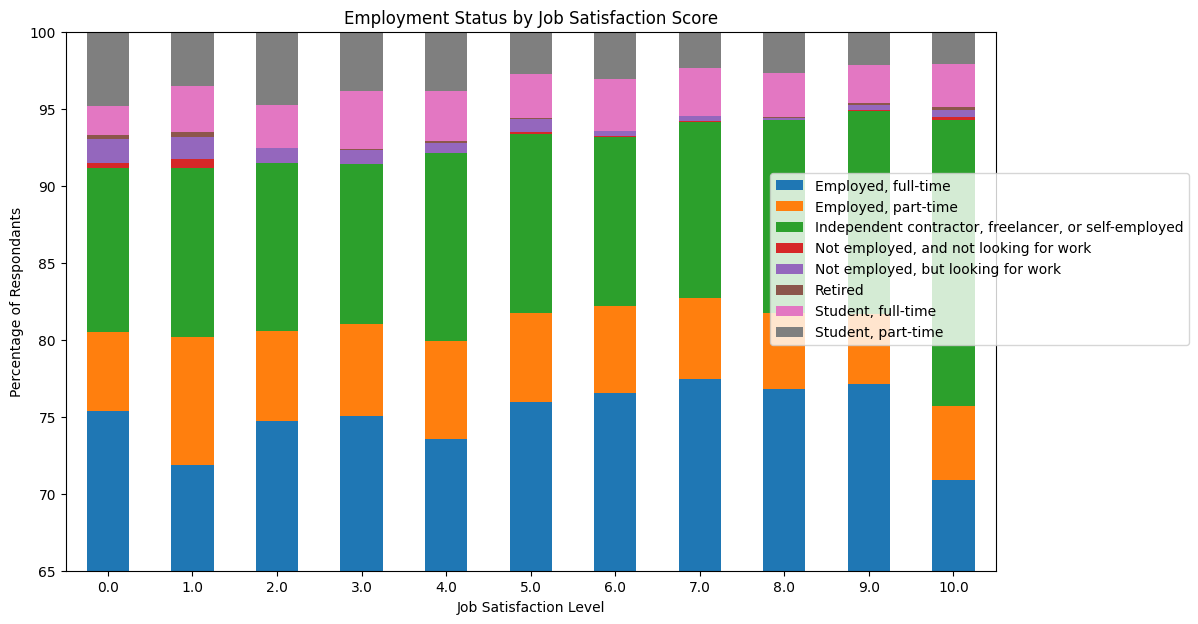

In [38]:
df_sat_emp.plot(figsize = (12, 7),
                kind = 'bar',
                stacked = True)
plt.xlabel('Job Satisfaction Level')
plt.xticks(rotation = 0)
plt.ylabel('Percentage of Respondants')
plt.ylim(65, 100) # scaled since the bottom half is just blue
plt.title('Employment Status by Job Satisfaction Score')
plt.legend(bbox_to_anchor = (.75, .75))
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [39]:
QUERY = """SELECT Age, LanguageAdmired
FROM main
WHERE Age IS NOT NULL
AND Age != 'Prefer not to say'
AND LanguageAdmired IS NOT NULL
"""
df_age_lang = pd.read_sql_query(QUERY, conn)
df_age_lang = df_age_lang.replace('Under 18 years old', '13-17 years old')
df_age_lang.head()

,Age,LanguageAdmired
0,35-44 years old,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
1,45-54 years old,C#
2,18-24 years old,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...
3,18-24 years old,C++;HTML/CSS;JavaScript;Lua;Python
4,13-17 years old,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...


In [40]:
df_age_lang['Language'] = df_age_lang['LanguageAdmired'].str.split(';')
df_age_lang = df_age_lang.explode('Language').reset_index(drop = True)
df_age_lang = df_age_lang.drop('LanguageAdmired', axis = 1)
df_age_lang.head(10)

,Age,Language
0,35-44 years old,Bash/Shell (all shells)
1,35-44 years old,Go
2,35-44 years old,HTML/CSS
3,35-44 years old,Java
4,35-44 years old,JavaScript
5,35-44 years old,Python
6,35-44 years old,TypeScript
7,45-54 years old,C#
8,18-24 years old,HTML/CSS
9,18-24 years old,Java


In [41]:
top5lang = list(df_age_lang['Language'].value_counts().head().index)
top5lang

['JavaScript', 'Python', 'SQL', 'HTML/CSS', 'TypeScript']

In [42]:
rows = df_age_lang[df_age_lang['Language'].isin(top5lang) == False] # attaining top 5 languages
df_age_lang = df_age_lang.drop(rows.index) # dropping rows to make visualization readable
df_age_lang.head()

,Age,Language
2,35-44 years old,HTML/CSS
4,35-44 years old,JavaScript
5,35-44 years old,Python
6,35-44 years old,TypeScript
8,18-24 years old,HTML/CSS


In [43]:
stacked_age_lang = df_age_lang.groupby('Age')['Language'].value_counts(normalize = True).reset_index()
stacked_age_lang

,Age,Language,proportion
0,13-17 years old,Python,0.276319
1,13-17 years old,HTML/CSS,0.257564
2,13-17 years old,JavaScript,0.229807
3,13-17 years old,TypeScript,0.126282
4,13-17 years old,SQL,0.110028
5,18-24 years old,Python,0.234633
6,18-24 years old,JavaScript,0.215114
7,18-24 years old,HTML/CSS,0.205787
8,18-24 years old,SQL,0.182174
9,18-24 years old,TypeScript,0.162291


In [44]:
stacked_age_lang['proportion'] = stacked_age_lang['proportion'].mul(100, fill_value = 0)

In [45]:
stacked_age_lang = stacked_age_lang.pivot(index = 'Age',
                                          columns = 'Language',
                                          values = 'proportion')
stacked_age_lang

Language,HTML/CSS,JavaScript,Python,SQL,TypeScript
Age,,,,,
13-17 years old,25.756439,22.980745,27.631908,11.002751,12.628157
18-24 years old,20.578734,21.511443,23.463306,18.217389,16.229128
25-34 years old,18.997152,21.732939,20.349984,20.582758,18.337167
35-44 years old,20.086838,22.634972,18.591290,22.170080,16.516819
45-54 years old,19.605707,22.339614,19.627492,25.944886,12.482300
55-64 years old,19.735026,22.605575,20.452664,28.374275,8.832459
65 years or older,21.806452,21.935484,25.032258,26.322581,4.903226


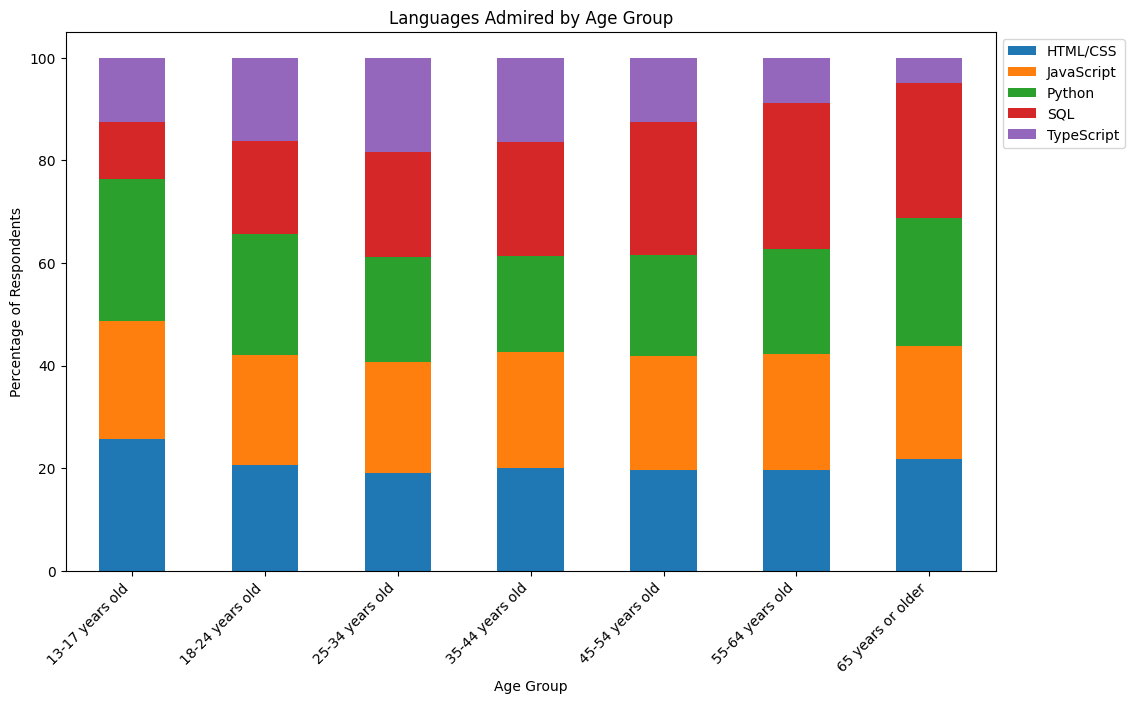

In [46]:
stacked_age_lang.plot(kind = 'bar',
                      stacked = True,
                      figsize = (12, 7))
plt.xlabel('Age Group')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Percentage of Respondents')
plt.title('Languages Admired by Age Group')
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [47]:
QUERY = """SELECT Employment, PlatformAdmired
FROM main
WHERE Employment IS NOT NULL
AND PlatformAdmired IS NOT NULL
"""
df_emp_plat = pd.read_sql_query(QUERY, conn)
df_emp_plat.head()

,Employment,PlatformAdmired
0,"Employed, full-time",Amazon Web Services (AWS);Heroku;Netlify
1,"Employed, full-time",Google Cloud
2,"Student, full-time",Amazon Web Services (AWS)
3,"Student, full-time",Cloudflare
4,"Student, full-time;Not employed, but looking f...",Vercel


In [48]:
df_emp_plat['Platform'] = df_emp_plat['PlatformAdmired'].str.split(';')
df_emp_plat = df_emp_plat.explode('Platform').reset_index(drop = True)
df_emp_plat = df_emp_plat.drop('PlatformAdmired', axis = 1)
df_emp_plat.head(10)

,Employment,Platform
0,"Employed, full-time",Amazon Web Services (AWS)
1,"Employed, full-time",Heroku
2,"Employed, full-time",Netlify
3,"Employed, full-time",Google Cloud
4,"Student, full-time",Amazon Web Services (AWS)
5,"Student, full-time",Cloudflare
6,"Student, full-time;Not employed, but looking f...",Vercel
7,"Independent contractor, freelancer, or self-em...",Amazon Web Services (AWS)
8,"Independent contractor, freelancer, or self-em...",Digital Ocean
9,"Independent contractor, freelancer, or self-em...",Firebase


In [49]:
df_emp_plat['Employment Status'] = df_emp_plat['Employment'].str.split(';')
df_emp_plat = df_emp_plat.explode('Employment Status')
df_emp_plat = df_emp_plat.drop('Employment', axis = 1)
df_emp_plat = df_emp_plat.reset_index(drop = True)

In [50]:
df_emp_plat['Platform'].value_counts()

Platform
Amazon Web Services (AWS)            16729
Microsoft Azure                       9110
Google Cloud                          7982
Cloudflare                            6187
Firebase                              4622
Vercel                                4424
Digital Ocean                         3999
Hetzner                               2226
Netlify                               2089
VMware                                1538
Supabase                              1530
Heroku                                1274
Managed Hosting                       1167
Linode, now Akamai                    1024
OVH                                   1006
Oracle Cloud Infrastructure (OCI)      953
Fly.io                                 931
Render                                 876
OpenShift                              710
Databricks                             613
Vultr                                  561
PythonAnywhere                         526
OpenStack                              478
Al

In [51]:
top10plat = list(df_emp_plat['Platform'].value_counts().head(10).index) # listing of top 10 platforms
rows = df_emp_plat[df_emp_plat['Platform'].isin(top10plat) == False] # rows to drop that aren't in top 10
df_emp_plat = df_emp_plat.drop(rows.index) # dropping indices of rows of platforms not in top 10

In [52]:
df_emp_plat['Employment Status'].value_counts()

Employment Status
Employed, full-time                                     34464
Independent contractor, freelancer, or self-employed    10937
Student, full-time                                       4904
Employed, part-time                                      2996
Not employed, but looking for work                       2704
Student, part-time                                       1925
Not employed, and not looking for work                    499
I prefer not to say                                       260
Retired                                                   217
Name: count, dtype: int64

In [53]:
stacked_emp_plat = df_emp_plat.groupby('Employment Status')['Platform'].value_counts(normalize = True).reset_index()
stacked_emp_plat['proportion'] = stacked_emp_plat['proportion'].mul(100, fill_value = 0)
stacked_emp_plat

,Employment Status,Platform,proportion
0,"Employed, full-time",Amazon Web Services (AWS),32.892293
1,"Employed, full-time",Microsoft Azure,18.364090
2,"Employed, full-time",Google Cloud,13.492340
3,"Employed, full-time",Cloudflare,8.826602
4,"Employed, full-time",Firebase,6.624304
...,...,...,...
85,"Student, part-time",Firebase,9.818182
86,"Student, part-time",Digital Ocean,6.805195
87,"Student, part-time",Netlify,4.259740
88,"Student, part-time",VMware,4.207792


In [54]:
stacked_emp_plat = stacked_emp_plat.pivot(index = 'Employment Status',
                                          columns = 'Platform',
                                          values = 'proportion')
stacked_emp_plat

Platform,Amazon Web Services (AWS),Cloudflare,Digital Ocean,Firebase,Google Cloud,Hetzner,Microsoft Azure,Netlify,VMware,Vercel
Employment Status,,,,,,,,,,
"Employed, full-time",32.892293,8.826602,6.232591,6.624304,13.492340,3.081476,18.364090,2.802925,2.306755,5.376625
"Employed, part-time",21.461949,12.049399,7.643525,8.711615,13.451268,6.508678,12.149533,3.971963,3.638184,10.413885
I prefer not to say,15.384615,16.538462,8.076923,9.230769,15.769231,6.538462,8.846154,4.615385,5.769231,9.230769
"Independent contractor, freelancer, or self-employed",24.988571,12.306848,8.942123,8.713541,13.294322,5.147664,12.956021,3.748743,2.276676,7.625491
"Not employed, and not looking for work",15.631263,15.831663,6.813627,10.220441,12.825651,4.208417,10.020040,6.012024,6.613226,11.823647
"Not employed, but looking for work",23.631657,10.724852,6.508876,11.168639,13.905325,2.773669,8.579882,6.767751,2.551775,13.387574
Retired,23.963134,9.216590,9.677419,6.912442,18.894009,2.304147,17.050691,3.686636,3.686636,4.608295
"Student, full-time",16.476346,16.068515,5.322186,11.092985,13.805057,4.282219,8.340131,5.689233,3.650082,15.273246
"Student, part-time",20.779221,11.324675,6.805195,9.818182,14.337662,4.051948,12.935065,4.259740,4.207792,11.480519


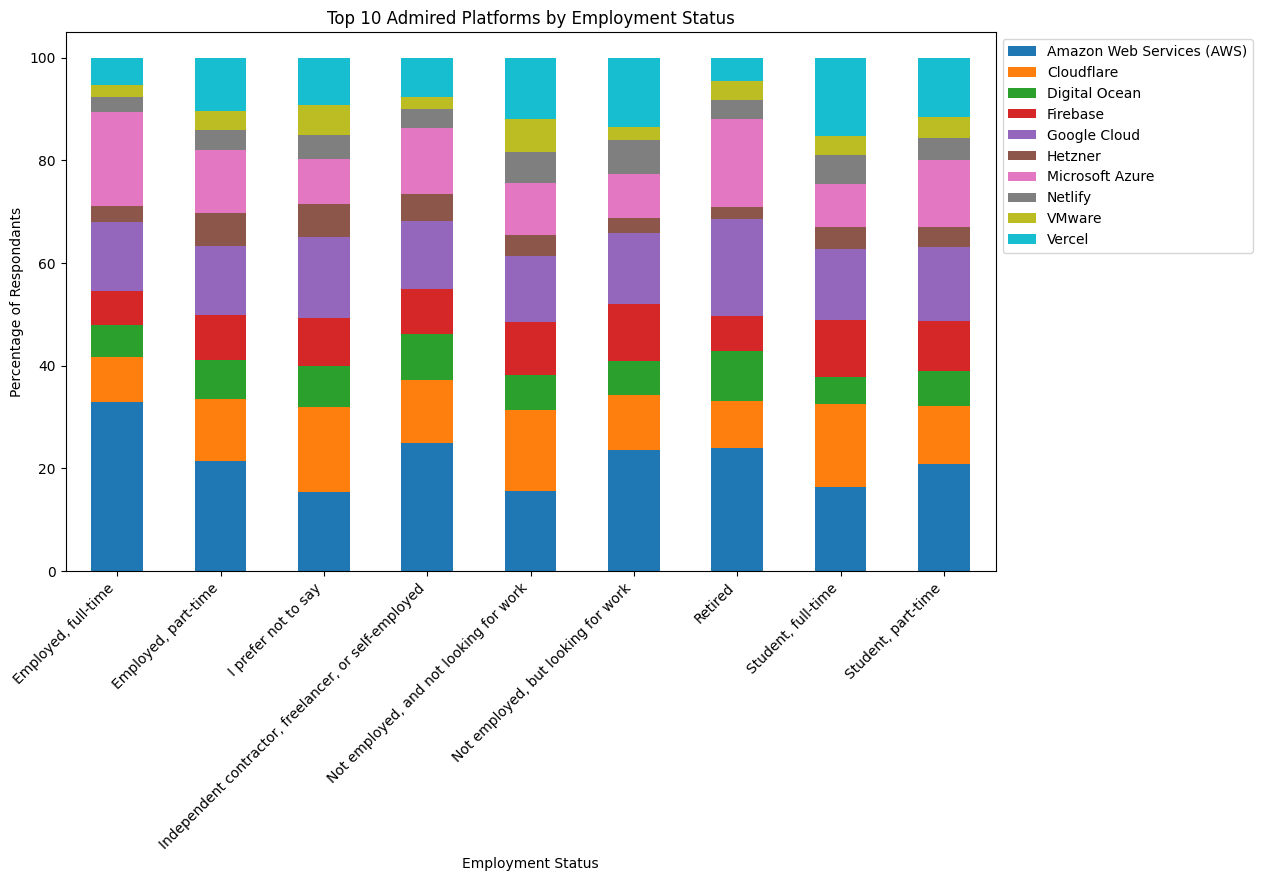

In [55]:
stacked_emp_plat.plot(kind = 'bar',
                      stacked = True,
                      figsize = (12, 7))
plt.xlabel('Employment Status')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Percentage of Respondants')
plt.title('Top 10 Admired Platforms by Employment Status')
plt.legend(bbox_to_anchor = (1, 1))
plt.show()

In [56]:
# close connection
conn.close()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
